This notebook is meant to demonstrate how to use the implied volatility functions. The first example uses a constant volatility and the black scholes pricing model. The second example uses market prices for calls and puts on Nvidia. 

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from impliedvolatility import impliedvol_bisection, impliedvol_newton
from blackscholes import call_price

In [82]:
S = 100
r = 0.05
T = 1

# for this example, we will use a constant volatility
true_sigma = 0.2

In [83]:
strikes = np.linspace(60, 140, 30)

market_prices = []
implied_vols = []

In [84]:
# calculate market prices using black scholes and recover implied volatility
for K in strikes:
    price = call_price(K, S, T, true_sigma, r)
    market_prices.append(price)
    iv = impliedvol_bisection(S, K, r, T, price, type = 'call')
    implied_vols.append(iv)

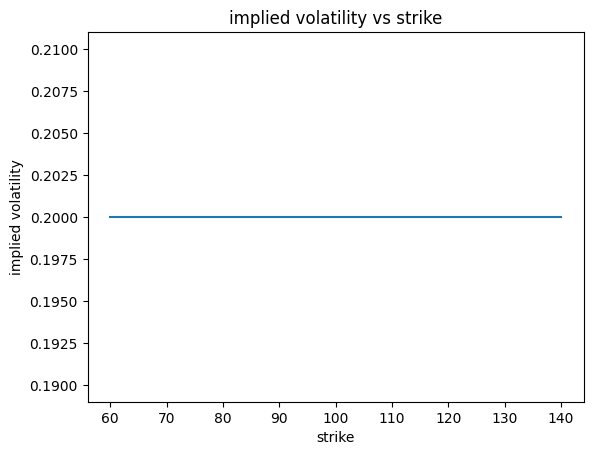

In [85]:
# the volatility should be the same for all because we used 0.2 for all
plt.plot(strikes, implied_vols)
plt.xlabel("strike")
plt.ylabel("implied volatility")
plt.title("implied volatility vs strike")
plt.show()

In [86]:
import pandas as pd
data = pd.read_csv("data.csv")
data.head()

,Strike,Price,Type
0,5,178.10,Call
1,10,173.72,Call
2,15,176.91,Call
3,20,161.09,Call
4,25,155.47,Call


In [87]:
S = 180      # current NVDA price (approx)
r = 0.04     # risk-free rate
T = 0.866    # time to expiration (Jan 2027)

In [88]:
# function to compute implied volatility for each option using newtons method
def compute_iv(row):
    K = row["Strike"]
    price = row["Price"]
    opt_type = row["Type"].lower()
    iv = impliedvol_newton(S, K, r, T, price, opt_type)
    return iv

In [89]:
# apply the function to calculate implied volatility for all options
data["IV"] = data.apply(compute_iv, axis = 1)

data.head()
# deep in the money / out of the money options may not return an implied volatility 

c:\docker\fm5252\project3\root.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  x = x - (fx / fpx)
c:\docker\fm5252\project3\blackscholes.py:5: RuntimeWarning: invalid value encountered in scalar divide
  d1 = lambda K, S, t, sigma, r: (np.log(S / K) + t * (0.5 * sigma ** 2 + r)) / (sigma * np.sqrt(t))


newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations
newton failed too many iterations


,Strike,Price,Type,IV
0,5,178.10,Call,NaN
1,10,173.72,Call,NaN
2,15,176.91,Call,NaN
3,20,161.09,Call,NaN
4,25,155.47,Call,NaN


In [90]:
# separate calls and puts for plotting the volatility smile
calls = data[data["Type"] == "Call"]
puts = data[data["Type"] == "Put"]

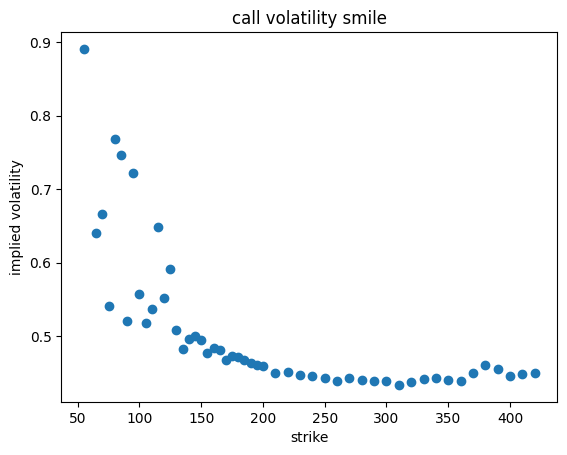

In [91]:
plt.figure()

plt.scatter(calls["Strike"], calls["IV"])
plt.xlabel("strike")
plt.ylabel("implied volatility")
plt.title("call volatility smile")

plt.show()

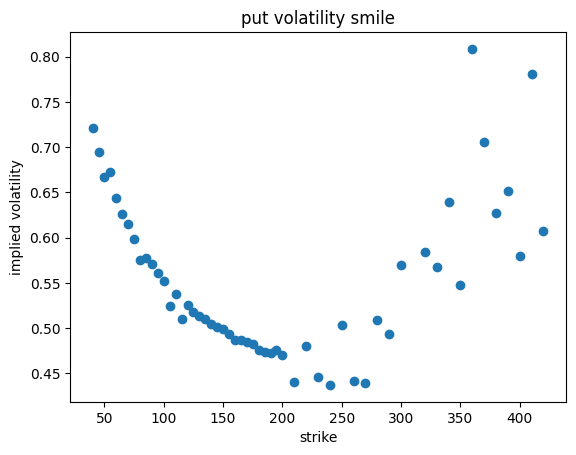

In [92]:
plt.figure()

plt.scatter(puts["Strike"], puts["IV"])
plt.xlabel("strike")
plt.ylabel("implied volatility")
plt.title("put volatility smile")

plt.show()